# 03b. Graph region-growing segmentation

This notebook replaces XYZ-only DBSCAN with a surface-compatibility graph. Points are connected when they are close and have compatible normal, curvature, and vertical continuity.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.segmentation.graph_region_growing import graph_region_growing_segmentation, cluster_size_table
from src.segmentation.metrics import clustering_scores

FEATURE_PATH = PROJECT_ROOT / 'data' / 'scanned_pointclouds' / 'synthetic_rockpile_exterior_surface_features.npz'
LABEL_PATH = PROJECT_ROOT / 'data' / 'labels' / 'synthetic_rockpile_exterior_graph_segmentation.npz'
TABLE_PATH = PROJECT_ROOT / 'outputs' / 'tables' / 'graph_segmentation_metrics.csv'
FIG_PATH = PROJECT_ROOT / 'outputs' / 'figures' / 'synthetic_rockpile_graph_region_growing.png'
LABEL_PATH.parent.mkdir(parents=True, exist_ok=True)
TABLE_PATH.parent.mkdir(parents=True, exist_ok=True)
FIG_PATH.parent.mkdir(parents=True, exist_ok=True)

In [2]:
features = np.load(FEATURE_PATH)
points = features['points_xyz']
true_labels = features['instance_labels']
normals = features['normals']
curvature = features['curvature']
print(points.shape, len(np.unique(true_labels)))

(68516, 3) 500


In [3]:
params = dict(
    radius_m=0.034,
    max_normal_angle_deg=26.0,
    max_curvature_delta=0.040,
    max_vertical_jump_m=0.041,
    min_cluster_points=20,
)
labels_graph = graph_region_growing_segmentation(points, normals, curvature, **params)
metrics = clustering_scores(true_labels, labels_graph)
metrics.update(cluster_size_table(labels_graph))
metrics.update(params)
metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(TABLE_PATH, index=False)
np.savez_compressed(LABEL_PATH, points_xyz=points, instance_labels=true_labels, labels_graph=labels_graph, normals=normals, curvature=curvature)
metrics_df

,adjusted_rand_index,normalized_mutual_info,n_true_fragments,n_predicted_clusters,noise_fraction,n_clusters,median_cluster_points,max_cluster_points,radius_m,max_normal_angle_deg,max_curvature_delta,max_vertical_jump_m,min_cluster_points
0,0.004092,0.525125,500,545,0.428834,545,38.0,2989,0.034,26.0,0.04,0.041,20


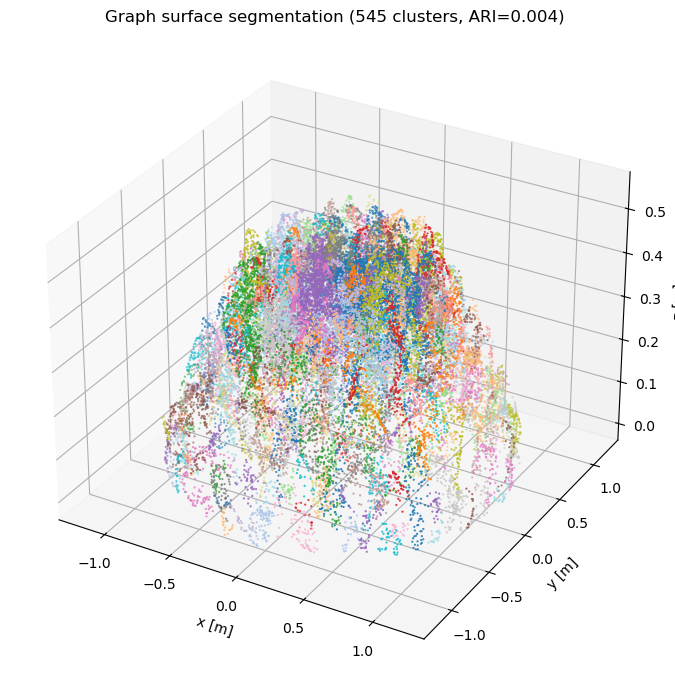

In [4]:
rng = np.random.default_rng(11)
idx = rng.choice(len(points), size=min(60000, len(points)), replace=False)
plot_labels = labels_graph[idx].astype(float)
plot_labels[plot_labels < 0] = np.nan

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[idx,0], points[idx,1], points[idx,2], c=plot_labels, s=0.35, cmap='tab20')
ax.set_title(f"Graph surface segmentation ({metrics['n_predicted_clusters']} clusters, ARI={metrics['adjusted_rand_index']:.3f})")
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]'); ax.set_zlabel('z [m]')
plt.tight_layout()
plt.savefig(FIG_PATH, dpi=180)
plt.show()